In [1]:
# ============================================================
# NOIMA v2 — Greek Sign Language Isolated Recognition
# Hybrid 1DCNN + Transformer (inspired by Kaggle 1st & 6th place)
# ============================================================
# Key insights applied:
# - Drop z-coordinate, use only x,y (both top solutions agree)
# - Add velocity (dx) and acceleration (dx2) features
# - Body-part specific MLPs + max hand aggregation
# - Conv1D blocks + Transformer hybrid architecture
# - OUSM loss, label smoothing 0.3, weight_decay 0.4
# - Normalize per-sequence to 0-mean, 1-std
# ============================================================

import os, json, glob, math, time, gc
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import GradScaler, autocast
import matplotlib.pyplot as plt
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# ============================================================
# DATA LOADING
# ============================================================
DATA_DIR = '/kaggle/input/gsl-isolated-keypoints/GSL_keypoints'
if not os.path.exists(DATA_DIR):
    DATA_DIR = '/kaggle/input/gsl-isolated-keypoints'
if not os.path.exists(os.path.join(DATA_DIR, 'label_map.json')):
    for root, dirs, files in os.walk('/kaggle/input'):
        if 'label_map.json' in files:
            DATA_DIR = root
            break

print(f'Data dir: {DATA_DIR}')

with open(os.path.join(DATA_DIR, 'label_map.json'), 'r', encoding='utf-8') as f:
    gloss_to_id = json.load(f)
id_to_gloss = {v: k for k, v in gloss_to_id.items()}
NUM_CLASSES = len(gloss_to_id)

def load_split(split_name):
    split_dir = os.path.join(DATA_DIR, split_name)
    batch_files = sorted(glob.glob(os.path.join(split_dir, 'batch_*.npz')))
    all_kps, all_labels = [], []
    for bf in batch_files:
        data = np.load(bf, allow_pickle=True)
        all_kps.append(data['keypoints'])
        all_labels.append(data['labels'])
    keypoints = np.concatenate(all_kps, axis=0)
    labels = np.concatenate(all_labels, axis=0)
    print(f'  {split_name}: {keypoints.shape[0]} samples, shape={keypoints.shape}')
    return keypoints, labels

print('Loading splits...')
train_kps, train_labels = load_split('train')
dev_kps, dev_labels = load_split('dev')
test_kps, test_labels = load_split('test')

MAX_FRAMES = train_kps.shape[1]  # 64
RAW_FEATURES = train_kps.shape[2]  # 225
print(f'\nClasses: {NUM_CLASSES} | Frames: {MAX_FRAMES} | Raw features: {RAW_FEATURES}')

Data dir: /kaggle/input/datasets/alexioualexandros/gsl-isolated-keypoints/GSL_keypoints
Loading splits...
  train: 11795 samples, shape=(11795, 64, 225)
  dev: 715 samples, shape=(715, 64, 225)
  test: 1379 samples, shape=(1379, 64, 225)

Classes: 310 | Frames: 64 | Raw features: 225


In [3]:
# ============================================================
# FEATURE ENGINEERING
# ============================================================
# Raw 225 features: 75 landmarks × [x, y, z]
# Landmark layout:
#   Pose:       11 landmarks, indices 0:33  (x,y,z interleaved)
#   Left hand:  21 landmarks, indices 33:96
#   Right hand: 21 landmarks, indices 96:159
#   Face:       22 landmarks, indices 159:225

# Step 1: Extract only x,y (drop z) — both top solutions agree z is unreliable
# Step 2: Add velocity (frame-to-frame difference) 
# Step 3: Add acceleration (2-frame difference)
# This triples our feature count but massively helps temporal modeling

def extract_xy(kps):
    """Extract only x,y coordinates, dropping z. Shape: (N, T, 225) -> (N, T, 150)"""
    N, T, F = kps.shape
    # Reshape to (N, T, 75, 3) then take only x,y
    kps_3d = kps.reshape(N, T, 75, 3)
    kps_xy = kps_3d[:, :, :, :2]  # (N, T, 75, 2)
    return kps_xy.reshape(N, T, 150)  # (N, T, 150)

def add_velocity_acceleration(kps):
    """Add velocity (dx) and acceleration (dx2) features.
    Input: (N, T, 150), Output: (N, T, 450)
    """
    # Velocity: difference between consecutive frames
    dx = np.zeros_like(kps)
    dx[:, 1:, :] = kps[:, 1:, :] - kps[:, :-1, :]
    
    # Acceleration: difference between frames 2 apart
    dx2 = np.zeros_like(kps)
    dx2[:, 2:, :] = kps[:, 2:, :] - kps[:, :-2, :]
    
    return np.concatenate([kps, dx, dx2], axis=-1)

def normalize_per_sequence(kps):
    """Normalize each sequence to 0-mean, 1-std (ignoring zero-padded frames)."""
    N, T, F = kps.shape
    for i in range(N):
        # Find real frames (non-zero)
        energy = np.abs(kps[i]).sum(axis=1)
        real_mask = energy > 0.01
        if real_mask.sum() > 0:
            real_frames = kps[i][real_mask]
            mean = real_frames.mean()
            std = real_frames.std() + 1e-8
            kps[i][real_mask] = (kps[i][real_mask] - mean) / std
    return kps

print('Processing features...')
t0 = time.time()

# Process all splits
for name, kps in [('train', train_kps), ('dev', dev_kps), ('test', test_kps)]:
    pass  # We'll process in-place below

train_xy = extract_xy(train_kps)
dev_xy = extract_xy(dev_kps)
test_xy = extract_xy(test_kps)

# Normalize before adding velocity (positions should be normalized)
train_xy = normalize_per_sequence(train_xy)
dev_xy = normalize_per_sequence(dev_xy)
test_xy = normalize_per_sequence(test_xy)

# Add velocity and acceleration
train_features = add_velocity_acceleration(train_xy)
dev_features = add_velocity_acceleration(dev_xy)
test_features = add_velocity_acceleration(test_xy)

NUM_FEATURES = train_features.shape[-1]  # 450
print(f'Final features: {NUM_FEATURES} (150 pos + 150 vel + 150 acc)')
print(f'Processing took {time.time()-t0:.1f}s')

# Free memory
del train_kps, dev_kps, test_kps, train_xy, dev_xy, test_xy
gc.collect()

Processing features...
Final features: 450 (150 pos + 150 vel + 150 acc)
Processing took 3.0s


701

In [4]:
# ============================================================
# DATASET WITH AUGMENTATIONS (inspired by both solutions)
# ============================================================
# Body part indices in the 150-dim xy feature vector:
# Pose:       11 landmarks × 2 = indices 0:22
# Left hand:  21 landmarks × 2 = indices 22:64
# Right hand: 21 landmarks × 2 = indices 64:106
# Face:       22 landmarks × 2 = indices 106:150
# (Same layout repeated 3x: positions, velocity, acceleration)

POSE_XY  = slice(0, 22)
LHAND_XY = slice(22, 64)
RHAND_XY = slice(64, 106)
FACE_XY  = slice(106, 150)

# For velocity block (offset by 150)
VEL_OFFSET = 150
ACC_OFFSET = 300

class SignDataset(Dataset):
    def __init__(self, features, labels, augment=False):
        self.features = features.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        x = self.features[idx].copy()  # (64, 450)
        label = self.labels[idx]

        # Compute mask before augmentation
        energy = np.sum(np.abs(x[:, :150]), axis=1)  # Only use position features
        mask = (energy > 0.01).astype(np.float32)
        n_real = int(mask.sum())

        if self.augment and n_real > 3:
            x = self._augment(x, n_real)
            # Recompute mask after augmentation
            energy = np.sum(np.abs(x[:, :150]), axis=1)
            mask = (energy > 0.01).astype(np.float32)

        return (
            torch.FloatTensor(x),
            torch.tensor(label, dtype=torch.long),
            torch.FloatTensor(mask)
        )

    def _augment(self, x, n_real):
        # 1) Temporal resample (0.7-1.3x speed) — from 1st place
        if np.random.random() < 0.5:
            x = self._resample(x, n_real)

        # 2) Horizontal flip (swap L/R hands) — from both solutions
        if np.random.random() < 0.5:
            x = self._flip(x)

        # 3) Spatial affine (scale + rotate) — from 1st place
        if np.random.random() < 0.5:
            x = self._spatial_affine(x)

        # 4) Temporal crop (remove 20% start/end) — from 6th place
        if np.random.random() < 0.5:
            x = self._temporal_crop(x, n_real)

        # 5) Temporal mask (zero out 10-30% of frames) — from 1st place
        if np.random.random() < 0.5:
            x = self._temporal_mask(x, n_real)

        # 6) Gaussian noise
        if np.random.random() < 0.3:
            noise = np.random.normal(0, 0.02, x.shape).astype(np.float32)
            mask_3d = (np.abs(x).sum(axis=1, keepdims=True) > 0.01)
            x = x + noise * mask_3d

        return x

    def _resample(self, x, n_real):
        """Temporal resampling — change sign speed."""
        rate = np.random.uniform(0.7, 1.3)
        new_len = max(3, int(n_real * rate))
        new_len = min(new_len, MAX_FRAMES)

        real_part = x[:n_real]
        # Interpolate
        indices = np.linspace(0, n_real - 1, new_len).astype(np.float32)
        idx_floor = np.floor(indices).astype(int)
        idx_ceil = np.minimum(idx_floor + 1, n_real - 1)
        frac = (indices - idx_floor)[:, None]
        resampled = real_part[idx_floor] * (1 - frac) + real_part[idx_ceil] * frac

        # Recompute velocity/acceleration after resampling
        pos = resampled[:, :150]
        vel = np.zeros_like(pos)
        vel[1:] = pos[1:] - pos[:-1]
        acc = np.zeros_like(pos)
        acc[2:] = pos[2:] - pos[:-2]
        resampled = np.concatenate([pos, vel, acc], axis=-1)

        # Pad back
        result = np.zeros_like(x)
        result[:new_len] = resampled
        return result

    def _flip(self, x):
        """Horizontal flip: negate x-coords, swap L/R hands."""
        flipped = x.copy()
        # For each of the 3 blocks (pos, vel, acc):
        for offset in [0, VEL_OFFSET, ACC_OFFSET]:
            # Negate x coordinates (every other value starting from 0 in each block)
            for i in range(offset, offset + 150, 2):
                flipped[:, i] = -flipped[:, i]
            # Swap left and right hand
            lh = slice(offset + 22, offset + 64)
            rh = slice(offset + 64, offset + 106)
            lh_copy = flipped[:, lh].copy()
            flipped[:, lh] = flipped[:, rh]
            flipped[:, rh] = lh_copy
        return flipped

    def _spatial_affine(self, x):
        """Random scale and rotation on x,y positions."""
        # Scale
        scale = np.random.uniform(0.8, 1.2)
        # Rotation
        angle = np.random.uniform(-np.pi / 6, np.pi / 6)  # ±30 degrees
        cos_a, sin_a = np.cos(angle), np.sin(angle)

        for offset in [0, VEL_OFFSET, ACC_OFFSET]:
            for lm in range(75):
                xi = offset + lm * 2
                yi = offset + lm * 2 + 1
                if xi < x.shape[1] and yi < x.shape[1]:
                    old_x = x[:, xi].copy()
                    old_y = x[:, yi].copy()
                    x[:, xi] = scale * (cos_a * old_x - sin_a * old_y)
                    x[:, yi] = scale * (sin_a * old_x + cos_a * old_y)
        return x

    def _temporal_crop(self, x, n_real):
        """Crop 10-20% from start or end."""
        if n_real < 10:
            return x
        crop_amount = np.random.randint(1, max(2, int(n_real * 0.2)))
        result = np.zeros_like(x)
        if np.random.random() < 0.5:  # Crop from start
            remaining = x[crop_amount:n_real]
            result[:len(remaining)] = remaining
        else:  # Crop from end
            remaining = x[:n_real - crop_amount]
            result[:len(remaining)] = remaining
        return result

    def _temporal_mask(self, x, n_real):
        """Zero out 10-30% of frames randomly."""
        mask_size = np.random.randint(max(1, int(n_real * 0.1)), max(2, int(n_real * 0.3)))
        start = np.random.randint(0, max(1, n_real - mask_size))
        x[start:start + mask_size] = 0.0
        return x


# Create datasets
train_dataset = SignDataset(train_features, train_labels, augment=True)
dev_dataset   = SignDataset(dev_features, dev_labels, augment=False)
test_dataset  = SignDataset(test_features, test_labels, augment=False)

BATCH_SIZE = 128

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)
dev_loader   = DataLoader(dev_dataset, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=256, shuffle=False,
                          num_workers=2, pin_memory=True)

# Sanity check
x_sample, y_sample, m_sample = train_dataset[0]
print(f'Sample: x={x_sample.shape}, label={y_sample.item()} ({id_to_gloss[y_sample.item()]}), real_frames={m_sample.sum().int().item()}')
print(f'Train batches: {len(train_loader)} | Dev: {len(dev_loader)} | Test: {len(test_loader)}')

Sample: x=torch.Size([64, 450]), label=61 (ΓΕΙΑ), real_frames=8
Train batches: 92 | Dev: 3 | Test: 6


In [5]:
# ============================================================
# MODEL: Hybrid Conv1D + Transformer (1st place style)
# with Body-Part MLPs (6th place style)
# ============================================================

class ECA(nn.Module):
    """Efficient Channel Attention — from 1st place."""
    def __init__(self, kernel_size=5):
        super().__init__()
        self.conv = nn.Conv1d(1, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        # x: (B, T, C)
        attn = x.mean(dim=1)  # (B, C)
        attn = self.conv(attn.unsqueeze(1)).squeeze(1)  # (B, C)
        attn = torch.sigmoid(attn).unsqueeze(1)  # (B, 1, C)
        return x * attn


class Conv1DBlock(nn.Module):
    """Efficient Conv1D block with depthwise conv + ECA — from 1st place."""
    def __init__(self, dim, kernel_size=17, expand_ratio=2, drop_rate=0.1):
        super().__init__()
        hidden = dim * expand_ratio
        self.expand = nn.Sequential(nn.Linear(dim, hidden), nn.Mish())
        self.dw_conv = nn.Conv1d(hidden, hidden, kernel_size, padding=kernel_size // 2, groups=hidden)
        self.bn = nn.BatchNorm1d(hidden)
        self.eca = ECA()
        self.project = nn.Linear(hidden, dim)
        self.drop = nn.Dropout(drop_rate)

    def forward(self, x):
        residual = x
        x = self.expand(x)
        x = self.dw_conv(x.transpose(1, 2)).transpose(1, 2)
        x = self.bn(x.transpose(1, 2)).transpose(1, 2)
        x = self.eca(x)
        x = self.project(x)
        x = self.drop(x)
        return x + residual


class TransformerBlock(nn.Module):
    """Pre-norm Transformer block — from 1st place."""
    def __init__(self, dim, nhead=8, expand=2, attn_dropout=0.1, drop_rate=0.1):
        super().__init__()
        self.norm1 = nn.BatchNorm1d(dim)
        self.attn = nn.MultiheadAttention(dim, nhead, dropout=attn_dropout, batch_first=True)
        self.drop1 = nn.Dropout(drop_rate)
        self.norm2 = nn.BatchNorm1d(dim)
        self.ff = nn.Sequential(
            nn.Linear(dim, dim * expand),
            nn.Mish(),
            nn.Linear(dim * expand, dim),
        )
        self.drop2 = nn.Dropout(drop_rate)

    def forward(self, x, mask=None):
        # Self-attention with pre-norm
        normed = self.norm1(x.transpose(1, 2)).transpose(1, 2)
        key_padding_mask = (mask == 0) if mask is not None else None
        attn_out, _ = self.attn(normed, normed, normed, key_padding_mask=key_padding_mask)
        x = x + self.drop1(attn_out)

        # Feed-forward with pre-norm
        normed = self.norm2(x.transpose(1, 2)).transpose(1, 2)
        x = x + self.drop2(self.ff(normed))
        return x


class BodyPartMLP(nn.Module):
    """Separate MLP for each body part — from 6th place."""
    def __init__(self, in_features, out_features):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.BatchNorm1d(out_features),
            nn.Mish(),
            nn.Dropout(0.1),
        )

    def forward(self, x):
        # x: (B*T, features)
        return self.mlp(x)


class NOIMAv2(nn.Module):
    """
    Hybrid 1DCNN + Transformer with body-part aware embeddings.
    Combines best of 1st place (conv+transformer) and 6th place (body-part MLPs).
    """
    def __init__(self, num_classes=310, dim=192, nhead=8, num_conv_blocks=3,
                 num_transformer_blocks=2, drop_rate=0.15, max_frames=64):
        super().__init__()
        self.dim = dim
        self.max_frames = max_frames

        # Body-part specific MLPs (each body part: pos + vel + acc)
        # Pose:  22 values × 3 (pos,vel,acc) = 66
        # LHand: 42 × 3 = 126
        # RHand: 42 × 3 = 126
        # Face:  44 × 3 = 132

        self.pose_mlp  = BodyPartMLP(66, dim // 4)
        self.lhand_mlp = BodyPartMLP(126, dim // 4)
        self.rhand_mlp = BodyPartMLP(126, dim // 4)
        self.face_mlp  = BodyPartMLP(132, dim // 4)

        # Fusion after body-part MLPs
        self.fusion = nn.Sequential(
            nn.Linear(dim * 3 // 4, dim),  # <-- FIX: 144 -> 192
            nn.BatchNorm1d(dim),
            nn.Mish(),
        )

        # Conv1D blocks (local temporal patterns) — from 1st place
        self.conv_blocks_1 = nn.ModuleList([
            Conv1DBlock(dim, kernel_size=17, drop_rate=drop_rate) for _ in range(num_conv_blocks)
        ])
        self.transformer_1 = TransformerBlock(dim, nhead=nhead, drop_rate=drop_rate)

        self.conv_blocks_2 = nn.ModuleList([
            Conv1DBlock(dim, kernel_size=17, drop_rate=drop_rate) for _ in range(num_conv_blocks)
        ])
        self.transformer_2 = TransformerBlock(dim, nhead=nhead, drop_rate=drop_rate)

        # Classification head — Late Dropout from 1st place
        self.head = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.Mish(),
            nn.Dropout(0.4),  # Late heavy dropout
            nn.Linear(dim * 2, num_classes),
        )

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _extract_body_parts(self, x):
        """Extract body part features from the 450-dim feature vector."""
        # Position features
        pose_pos  = x[:, :, 0:22]
        lhand_pos = x[:, :, 22:64]
        rhand_pos = x[:, :, 64:106]
        face_pos  = x[:, :, 106:150]

        # Velocity features
        pose_vel  = x[:, :, 150:172]
        lhand_vel = x[:, :, 172:214]
        rhand_vel = x[:, :, 214:256]
        face_vel  = x[:, :, 256:300]

        # Acceleration features
        pose_acc  = x[:, :, 300:322]
        lhand_acc = x[:, :, 322:364]
        rhand_acc = x[:, :, 364:406]
        face_acc  = x[:, :, 406:450]

        # Concatenate pos+vel+acc per body part
        pose  = torch.cat([pose_pos, pose_vel, pose_acc], dim=-1)     # (B, T, 66)
        lhand = torch.cat([lhand_pos, lhand_vel, lhand_acc], dim=-1)  # (B, T, 126)
        rhand = torch.cat([rhand_pos, rhand_vel, rhand_acc], dim=-1)  # (B, T, 126)
        face  = torch.cat([face_pos, face_vel, face_acc], dim=-1)     # (B, T, 132)

        return pose, lhand, rhand, face

    def forward(self, x, mask=None):
        """
        x: (B, T, 450)
        mask: (B, T)
        """
        B, T, _ = x.shape

        # 1. Extract body parts and process with separate MLPs
        pose, lhand, rhand, face = self._extract_body_parts(x)

        pose_fts  = self.pose_mlp(pose.reshape(B * T, -1))
        lhand_fts = self.lhand_mlp(lhand.reshape(B * T, -1))
        rhand_fts = self.rhand_mlp(rhand.reshape(B * T, -1))
        face_fts  = self.face_mlp(face.reshape(B * T, -1))

        # Max aggregation for hands — from 6th place (handles dominant hand)
        hand_fts = torch.stack([lhand_fts, rhand_fts], dim=-1).amax(dim=-1)

        # Concatenate: pose + hands(max) + face = dim//4 * 3
        # But we need dim, so we add the missing dim//4 via face
        fts = torch.cat([pose_fts, hand_fts, face_fts], dim=-1)  # (B*T, dim*3/4)

        # Fusion to target dim
        fts = self.fusion(fts)
        fts = fts.view(B, T, -1)  # (B, T, dim)

        # 2. Conv1D blocks + Transformer (Stage 1)
        for conv in self.conv_blocks_1:
            fts = conv(fts)
        fts = self.transformer_1(fts, mask)

        # 3. Conv1D blocks + Transformer (Stage 2)
        for conv in self.conv_blocks_2:
            fts = conv(fts)
        fts = self.transformer_2(fts, mask)

        # 4. Masked average pooling
        if mask is not None:
            mask_exp = mask.unsqueeze(-1)  # (B, T, 1)
            fts = (fts * mask_exp).sum(dim=1) / mask_exp.sum(dim=1).clamp(min=1)
        else:
            fts = fts.mean(dim=1)

        # 5. Classification
        return self.head(fts)


# Initialize
model = NOIMAv2(
    num_classes=NUM_CLASSES,
    dim=192,
    nhead=8,
    num_conv_blocks=3,
    num_transformer_blocks=2,
    drop_rate=0.15,
    max_frames=MAX_FRAMES,
).to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Parameters: {total_params:,} ({total_params * 4 / 1e6:.1f} MB)')

# Quick test
with torch.no_grad():
    dummy = torch.randn(2, MAX_FRAMES, NUM_FEATURES).to(device)
    dummy_mask = torch.ones(2, MAX_FRAMES).to(device)
    out = model(dummy, dummy_mask)
    print(f'Output shape: {out.shape}')

Parameters: 1,772,212 (7.1 MB)
Output shape: torch.Size([2, 310])


In [6]:
# ============================================================
# LOSS: Smooth Cross-Entropy + OUSM — from 6th place
# ============================================================

class SmoothCEWithOUSM(nn.Module):
    """Label-smoothed CE that excludes the K hardest samples (OUSM)."""
    def __init__(self, num_classes, smoothing=0.3, ousm_k=3):
        super().__init__()
        self.smoothing = smoothing
        self.num_classes = num_classes
        self.ousm_k = ousm_k

    def forward(self, logits, targets):
        # One-hot with smoothing
        with torch.no_grad():
            one_hot = torch.zeros_like(logits).scatter(1, targets.unsqueeze(1), 1.0)
            one_hot = one_hot * (1 - self.smoothing) + self.smoothing / self.num_classes

        log_probs = F.log_softmax(logits, dim=1)
        loss_per_sample = -(one_hot * log_probs).sum(dim=1)  # (B,)

        # OUSM: exclude top-K hardest samples
        if self.ousm_k > 0 and len(loss_per_sample) > self.ousm_k:
            _, keep_idx = loss_per_sample.topk(
                len(loss_per_sample) - self.ousm_k, largest=False
            )
            loss_per_sample = loss_per_sample[keep_idx]

        return loss_per_sample.mean()

criterion = SmoothCEWithOUSM(NUM_CLASSES, smoothing=0.3, ousm_k=3)
print('Loss: SmoothCE(smoothing=0.3) + OUSM(k=3) ✓')

Loss: SmoothCE(smoothing=0.3) + OUSM(k=3) ✓


In [7]:
# ============================================================
# TRAINING CONFIG — inspired by both solutions
# ============================================================

NUM_EPOCHS = 100
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.4       # from 6th place
WARMUP_EPOCHS = 10        # 10% warmup
PATIENCE = 20

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    betas=(0.9, 0.999)
)

def get_lr_lambda(epoch):
    if epoch < WARMUP_EPOCHS:
        return (epoch + 1) / WARMUP_EPOCHS
    progress = (epoch - WARMUP_EPOCHS) / (NUM_EPOCHS - WARMUP_EPOCHS)
    return 0.5 * (1 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, get_lr_lambda)
scaler = GradScaler()

print(f'Optimizer: AdamW (lr={LEARNING_RATE}, wd={WEIGHT_DECAY})')
print(f'Schedule: {WARMUP_EPOCHS} warmup + cosine decay')
print(f'Epochs: {NUM_EPOCHS} (patience={PATIENCE})')

Optimizer: AdamW (lr=0.0003, wd=0.4)
Schedule: 10 warmup + cosine decay
Epochs: 100 (patience=20)


In [8]:
# ============================================================
# TRAINING LOOP
# ============================================================

def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for x, labels, mask in loader:
        x, labels, mask = x.to(device), labels.to(device), mask.to(device)
        optimizer.zero_grad()

        with autocast():
            logits = model(x, mask)
            loss = criterion(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item() * labels.size(0)
        correct += (logits.argmax(-1) == labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    for x, labels, mask in loader:
        x, labels, mask = x.to(device), labels.to(device), mask.to(device)
        with autocast():
            logits = model(x, mask)
            loss = criterion(logits, labels)

        total_loss += loss.item() * labels.size(0)
        preds = logits.argmax(-1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)


# ===== TRAIN =====
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0
patience_counter = 0
best_epoch = 0
SAVE_PATH = '/kaggle/working/noima_v2_best.pt'

# Model soup: collect checkpoints for averaging — from 6th place
soup_checkpoints = []
SOUP_START = 70  # Start collecting after epoch 70

print(f'{"Ep":>4} {"TrLoss":>8} {"TrAcc":>8} {"VaLoss":>8} {"VaAcc":>8} {"LR":>10} {"Time":>5}')
print('=' * 65)

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
    val_loss, val_acc, _, _ = evaluate(model, dev_loader, criterion, device)

    scheduler.step()
    lr = optimizer.param_groups[0]['lr']
    elapsed = time.time() - t0

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(lr)

    # Model soup: save checkpoint state
    if epoch >= SOUP_START:
        soup_checkpoints.append({k: v.cpu().clone() for k, v in model.state_dict().items()})
        if len(soup_checkpoints) > 10:
            soup_checkpoints.pop(0)

    marker = ''
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_epoch = epoch
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'val_acc': val_acc,
        }, SAVE_PATH)
        marker = ' ★'
    else:
        patience_counter += 1

    print(f'{epoch+1:>4} {train_loss:>8.4f} {train_acc:>7.1%} {val_loss:>8.4f} {val_acc:>7.1%} {lr:>10.6f} {elapsed:>4.0f}s{marker}')

    if patience_counter >= PATIENCE:
        print(f'\nEarly stopping. Best: {best_val_acc:.1%} @ epoch {best_epoch+1}')
        break

# Model Soup: average last N checkpoints — from 6th place
if len(soup_checkpoints) >= 3:
    print(f'\nApplying Model Soup (averaging {len(soup_checkpoints)} checkpoints)...')
    avg_state = {}
    for key in soup_checkpoints[0]:
        avg_state[key] = torch.stack([ck[key].float() for ck in soup_checkpoints]).mean(0)
    model.load_state_dict(avg_state)
    soup_loss, soup_acc, _, _ = evaluate(model, dev_loader, criterion, device)
    print(f'Soup Val Acc: {soup_acc:.1%} (best single: {best_val_acc:.1%})')

    if soup_acc > best_val_acc:
        torch.save({'model_state_dict': model.state_dict(), 'val_acc': soup_acc}, SAVE_PATH)
        best_val_acc = soup_acc
        print('Soup is better! Saved ✓')
    else:
        checkpoint = torch.load(SAVE_PATH)
        model.load_state_dict(checkpoint['model_state_dict'])
        print('Single best is better, keeping it.')

print(f'\nFinal best validation accuracy: {best_val_acc:.1%}')

  Ep   TrLoss    TrAcc   VaLoss    VaAcc         LR  Time
   1   5.5615    6.1%   5.3337    5.9%   0.000060   18s ★
   2   5.1427    9.4%   4.9896   11.2%   0.000090   15s ★
   3   4.8793   15.1%   4.7183   22.9%   0.000120   15s ★
   4   4.5925   23.7%   4.4334   30.3%   0.000150   15s ★
   5   4.3075   31.9%   4.0698   43.5%   0.000180   15s ★
   6   4.0904   38.6%   3.8386   49.2%   0.000210   15s ★
   7   3.9087   45.1%   3.7024   51.9%   0.000240   15s ★
   8   3.7563   50.1%   3.5941   55.4%   0.000270   15s ★
   9   3.6231   54.7%   3.4999   60.1%   0.000300   15s ★
  10   3.5071   59.1%   3.3995   62.2%   0.000300   15s ★
  11   3.3914   62.8%   3.3464   62.8%   0.000300   15s ★
  12   3.2959   66.2%   3.2183   67.8%   0.000300   15s ★
  13   3.2230   69.1%   3.2046   66.7%   0.000299   15s
  14   3.1542   72.0%   3.0949   71.7%   0.000299   15s ★
  15   3.0950   74.1%   3.0039   76.8%   0.000298   15s ★
  16   3.0538   75.1%   3.0577   74.0%   0.000297   15s
  17   3.0146   77

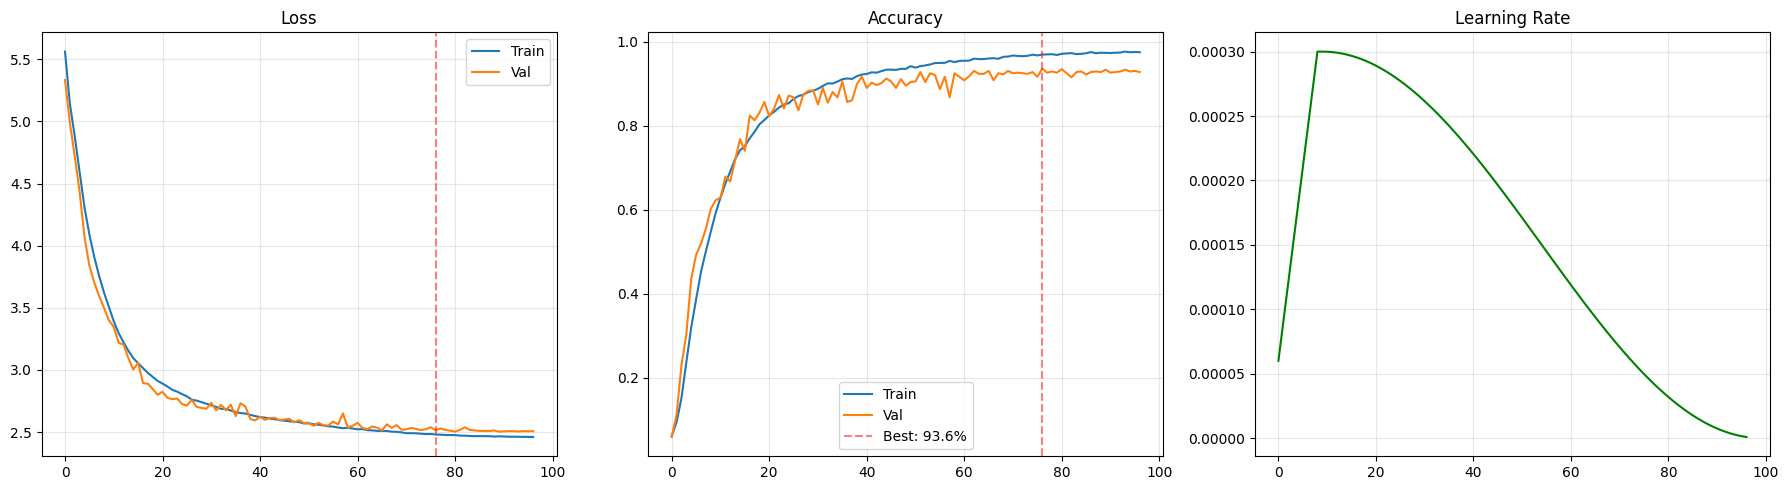

In [9]:
# ============================================================
# TRAINING CURVES
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Val')
axes[0].axvline(best_epoch, color='red', ls='--', alpha=0.5)
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_acc'], label='Train')
axes[1].plot(history['val_acc'], label='Val')
axes[1].axvline(best_epoch, color='red', ls='--', alpha=0.5, label=f'Best: {best_val_acc:.1%}')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

axes[2].plot(history['lr'], color='green')
axes[2].set_title('Learning Rate'); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves_v2.png', dpi=150)
plt.show()

In [10]:
# ============================================================
# TEST EVALUATION
# ============================================================
checkpoint = torch.load(SAVE_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])

test_loss, test_acc, test_preds, test_true = evaluate(model, test_loader, criterion, device)

# Top-K accuracy
@torch.no_grad()
def top_k_accuracy(model, loader, k=5):
    model.eval()
    correct, total = 0, 0
    for x, labels, mask in loader:
        x, labels, mask = x.to(device), labels.to(device), mask.to(device)
        with autocast():
            logits = model(x, mask)
        topk = logits.topk(k, dim=-1).indices
        correct += (topk == labels.unsqueeze(-1)).any(-1).sum().item()
        total += labels.size(0)
    return correct / total

top5 = top_k_accuracy(model, test_loader, k=5)
top10 = top_k_accuracy(model, test_loader, k=10)

print(f'{"="*50}')
print(f'TEST ACCURACY:     {test_acc:.1%}')
print(f'TOP-5 ACCURACY:    {top5:.1%}')
print(f'TOP-10 ACCURACY:   {top10:.1%}')
print(f'{"="*50}')

TEST ACCURACY:     92.9%
TOP-5 ACCURACY:    98.4%
TOP-10 ACCURACY:   98.8%


In [11]:
# ============================================================
# EXPORT
# ============================================================
import shutil

# Save config
config = {
    'num_classes': NUM_CLASSES, 'dim': 192, 'nhead': 8,
    'num_conv_blocks': 3, 'num_transformer_blocks': 2,
    'max_frames': MAX_FRAMES, 'num_features': NUM_FEATURES,
    'test_accuracy': test_acc, 'test_top5': top5, 'test_top10': top10,
    'body_parts_xy': {
        'pose': [0, 22], 'left_hand': [22, 64],
        'right_hand': [64, 106], 'face': [106, 150]
    },
    'feature_blocks': {'positions': [0, 150], 'velocity': [150, 300], 'acceleration': [300, 450]},
}

with open('/kaggle/working/model_config_v2.json', 'w') as f:
    json.dump(config, f, indent=2)

shutil.copy(os.path.join(DATA_DIR, 'label_map.json'), '/kaggle/working/label_map.json')

print('Saved files:')
for f in sorted(os.listdir('/kaggle/working/')):
    size = os.path.getsize(f'/kaggle/working/{f}')
    print(f'  {f} ({size/1e6:.1f} MB)')

Saved files:
  __notebook__.ipynb (0.2 MB)
  label_map.json (0.0 MB)
  model_config_v2.json (0.0 MB)
  noima_v2_best.pt (7.2 MB)
  training_curves_v2.png (0.1 MB)
